<a href="https://colab.research.google.com/github/IrynaSukhoverkhova/my-first-work-place/blob/main/HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

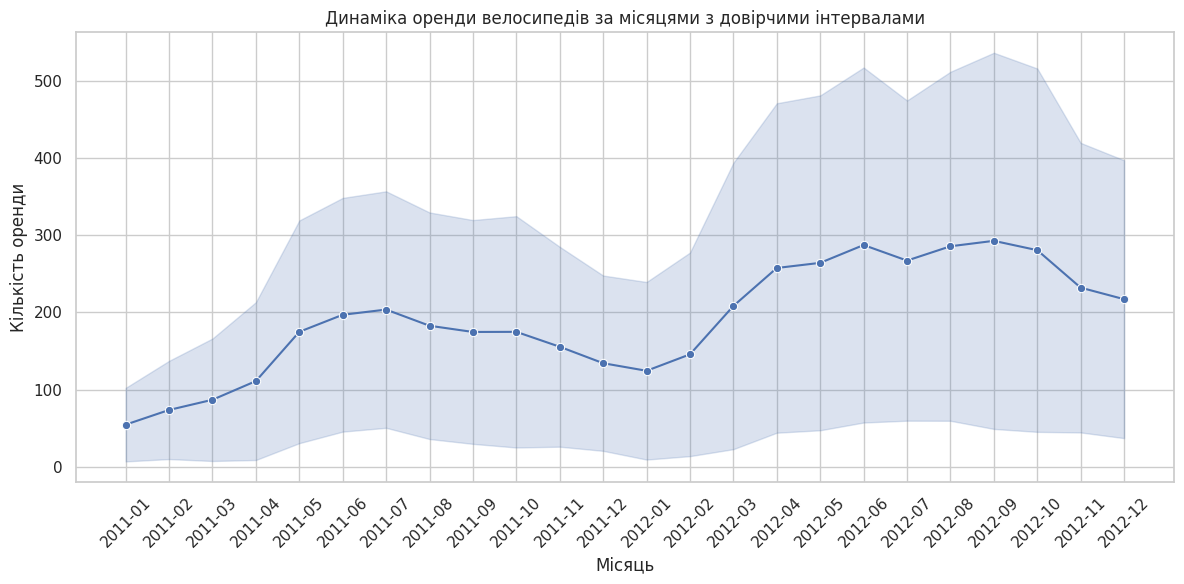

In [3]:
# 1. Створюємо колонку 'month_year'
df['month_year'] = df.index.to_period('M').astype(str)

# 2. Налаштовуємо розмір фігури
plt.figure(figsize=(12, 6))

# 3. Будуємо лінійний графік
sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    errorbar='sd',
    marker='o'
)

# 4. Додаємо підписи та форматування
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Найбільша невизначеність** спостерігається у весняно-літній та осінній періоди 2012 року, а саме:

**Червень 2012 (2012-06)** — найширший довірчий інтервал (верхня межа перевищує 500 оренд, тоді як середня лінія знаходиться на рівні ~290).

**Вересень 2012 (2012-09)** та **Серпень 2012 (2012-08)** — також демонструють значний розмах невизначеності (верхня межа сягає понад 500 оренд).

**Квітень—Травень 2012 (2012-04, 2012-05)** — помітно висока варіативність порівняно з зимовими місяцями.

**Основний висновок:** У теплий сезон 2012 року попит на оренду суттєво коливався (наприклад, через різницю між буднями та вихідними, або залежно від погодних умов), що створює найбільший розкид даних відносно середнього значення. Натомість у зимові місяці (наприклад, 2011-01...2011-03 або 2012-01) невизначеність найменша — смуга дуже вузька, а попит стабільно низький.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

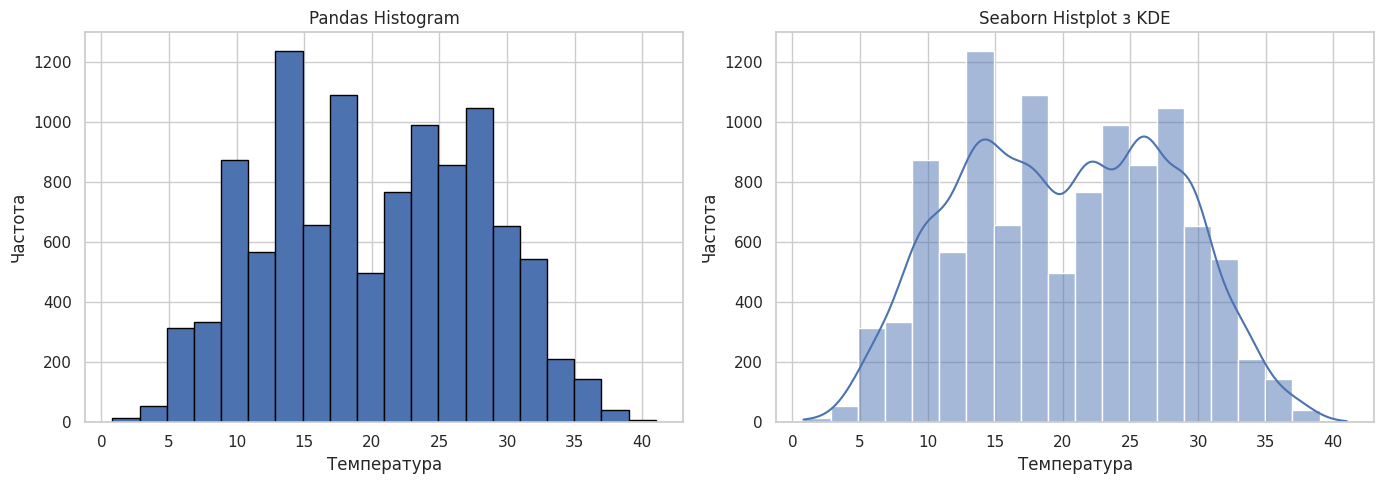

In [5]:
# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гістограма Pandas (колонка 'temp' або 'atemp')
df['temp'].plot.hist(
    bins=20,
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title('Pandas Histogram')
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

# 2. Гістограма Seaborn з оцінкою щільності (kde=True)
sns.histplot(
    data=df,
    x='temp',
    bins=20,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Seaborn Histplot з KDE')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

**1. Яка візуальна різниця між Pandas та Seaborn гістограмами?**

**Стилістика та сітка:** Seaborn автоматично застосовує власну тему (фонову сітку, м'якіші кольори стовпців та межі), що робить графік більш готовим до презентацій, тоді як стандартний Pandas plot без додаткових налаштувань має базований на Matplotlib лаконічний вигляд.

**Додаткові шари:** завдяки параметру kde=True у Seaborn зверху гістограми накладається гладка крива лінії розподілу.

**2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?**

**Це лінія KDE (Kernel Density Estimation)** — ядерна оцінка щільності розподілу.

Це згладжена крива, яка показує загальну форму розподілу даних. Вона прибирає різкі кути та сходинки між окремими бінами (стовпчиками) і демонструє ймовірну щільність даних у кожній точці як єдину плавну хвилю.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

/tmp/ipykernel_1016/3736397896.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


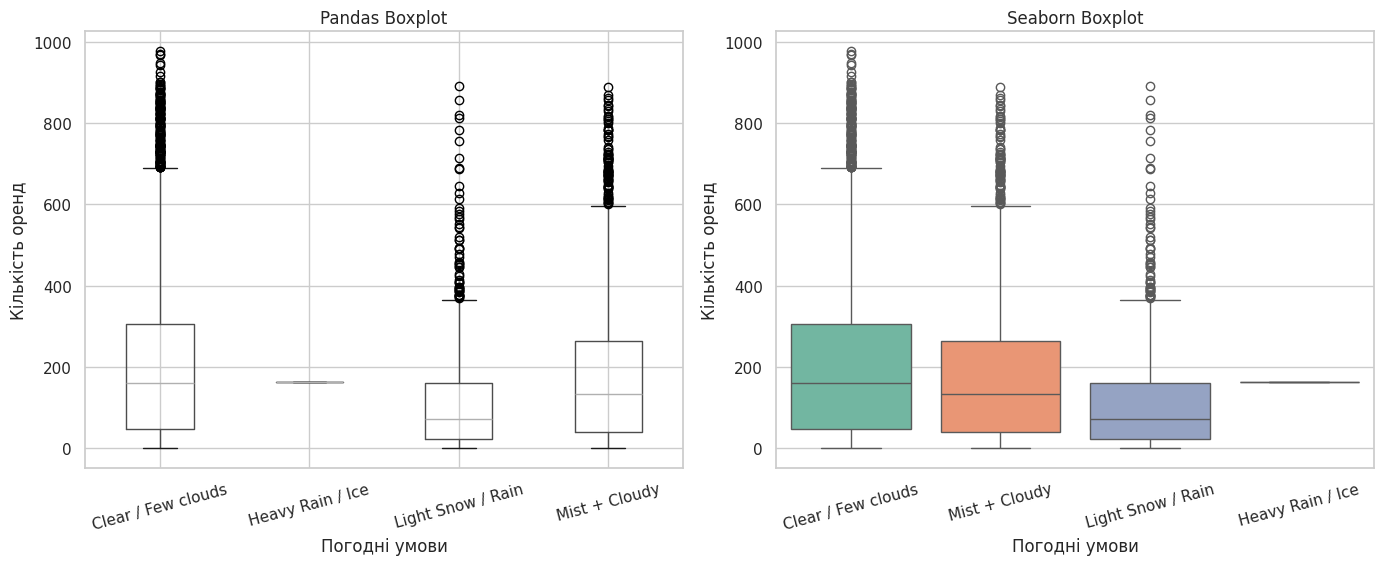

In [6]:
# Словник з інтерпретацією категорій погоди (згідно з описом дасету Yulu/Bike Sharing)
weather_labels = {
    1: 'Clear / Few clouds',
    2: 'Mist + Cloudy',
    3: 'Light Snow / Rain',
    4: 'Heavy Rain / Ice'
}

# Додаємо текстову колонку з розшифровкою
df['weather_label'] = df['weather'].map(weather_labels)

# Створюємо фігуру з двома сабплотами
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Boxplot Pandas
df.boxplot(column='count', by='weather_label', ax=axes[0])
axes[0].set_title('Pandas Boxplot')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')
plt.suptitle('')  # Прибираємо автоматичний заголовок pandas

# 2. Boxplot Seaborn
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Seaborn Boxplot')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

# Розрачуємо кут нахилу підписів для кращої читабельності
for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Яка візуальна різниця між Pandas та Seaborn бокс-плотами?**

**Кольори та палітра:** Seaborn за замовчуванням зафарбовує кожну ящик-категорію в окремий колір з власної палітри, тоді як Pandas будує монохромні (білі) ящики з кольоровими контурами та медіаною.

**Стиль викидів (outliers):** Seaborn за замовчуванням стилізує точки-викиди під колір заливки або темний сірий, роблячи їх менш агресивними, тоді як Pandas зображує їх стандартними маркерами Matplotlib (колами).

**Сітка та межі:** у Seaborn застосовується загальна тема з фоновою сіткою без зайвих бічних рамок, що робить візуалізацію охайнішою та легшою для сприйняття. Pandas додає сітку безпосередньо всередину графіка та зберігає чіткі межі по периметру.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


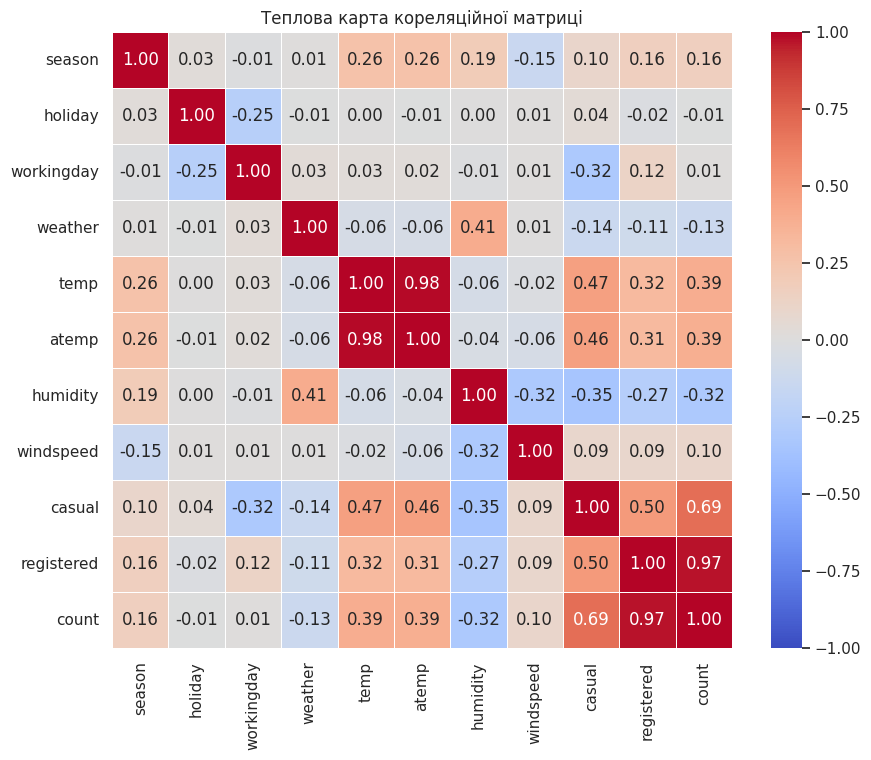

In [8]:
# 1. Відбираємо лише числові колонки для кореляції
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# 2. Будуємо теплову карту (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Теплова карта кореляційної матриці')
plt.show()

**1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?**

- **temp **(фактична температура) та **atemp** (відчувальна температура) — мають найвищу позитивну кореляцію з count (близько 0.39–0.40). Чим тепліша погода, тим більше оренд.
- Якщо у датасеті є розбивка на registered (зареєстровані) та casual (випадкові користувачі), вони матимуть найвищу кореляцію з count (понад 0.7–0.97), оскільки count = casual + registered.

**2. Яка кореляція між temp та atemp? Чому?**

- **Кореляція:** майже ідеальна позитивна кореляція ($\approx 0.98 - 0.99$).
- **Чому:** temp — це фактична температура повітря, а atemp ("feels like") — температура, що відчувається людиною (і розраховується на основі фактичної температури, вологості та вітру). Оскільки ці величини прямо залежать одна від одної, їхні зміни відбуваються практично синхронно.

**3. Які змінні мають негативну кореляцію?**
- **humidity (вологість)**: має найвідчутніший негативний зв'язок із count (близько -0.32). Висока вологість зменшує комфорт і бажання кататися.
- **weather (погодні умови)**: кодується так, що вищі значення відповідають гіршій погоді (дощ, сніг), тому показує негативну кореляцію з кількістю оренд.
- **windspeed та humidity:** також показують помірну негативну кореляцію між собою або з попитом у певні періоди.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


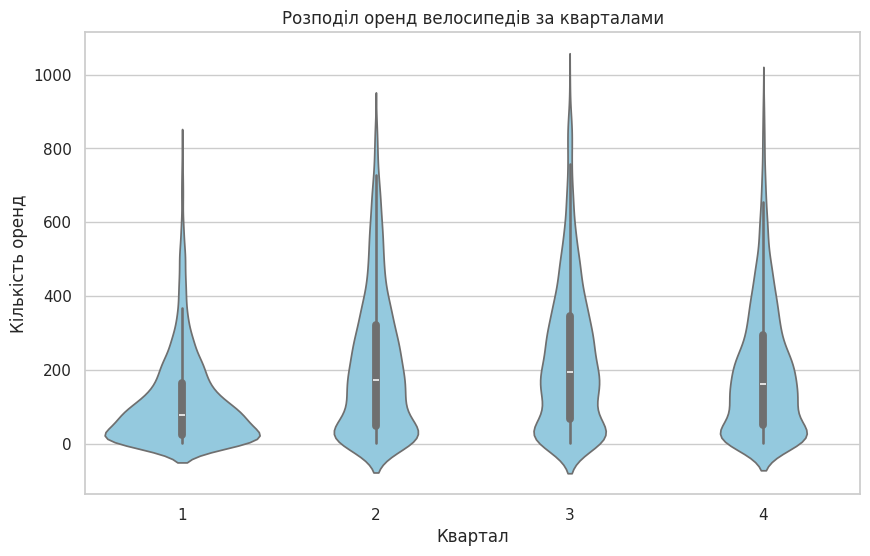

In [19]:
# 1. Створюємо колонку 'quarter' з індексу datetime
df['quarter'] = df.index.quarter

# 2. Побудова Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='quarter',
    y='count',
    color='skyblue'
)

plt.title('Розподіл оренд велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')

plt.show()

**1. Що показує товщина violin plot?**

Товщина (ширина фігури в певній точці) відображає щільність ймовірності даних (KDE). Чим ширша скрипка на певній висоті значення оренд, тим більше спостережень/годин мають саме таку кількість оренд.

**2. В якому кварталі найбільша варіабельність оренди?**

У 3-му кварталі (Q3) — літньо-осінньому (липень – вересень) або 2-му кварталі (Q2). Вони демонструють найбільшу висоту та розмах фігури вздовж осі Y (від нуля до максимальних значень), що свідчить про високу дисперсію та варіабельність попиту в теплий сезон.

**3. Яка перевага violin plot над звичайним box plot?**

Відображення мультимодальності та форми: Box plot показує лише 5 числових підсумків (медіану, квартилі, мінімум, максимум та викиди), приховуючи реальну форму розподілу. Violin plot додатково відображає підняття та вершини (мультимодальність) у даних — наприклад, якщо є два виражених піки попиту (ранкові та вечірні години пік).

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

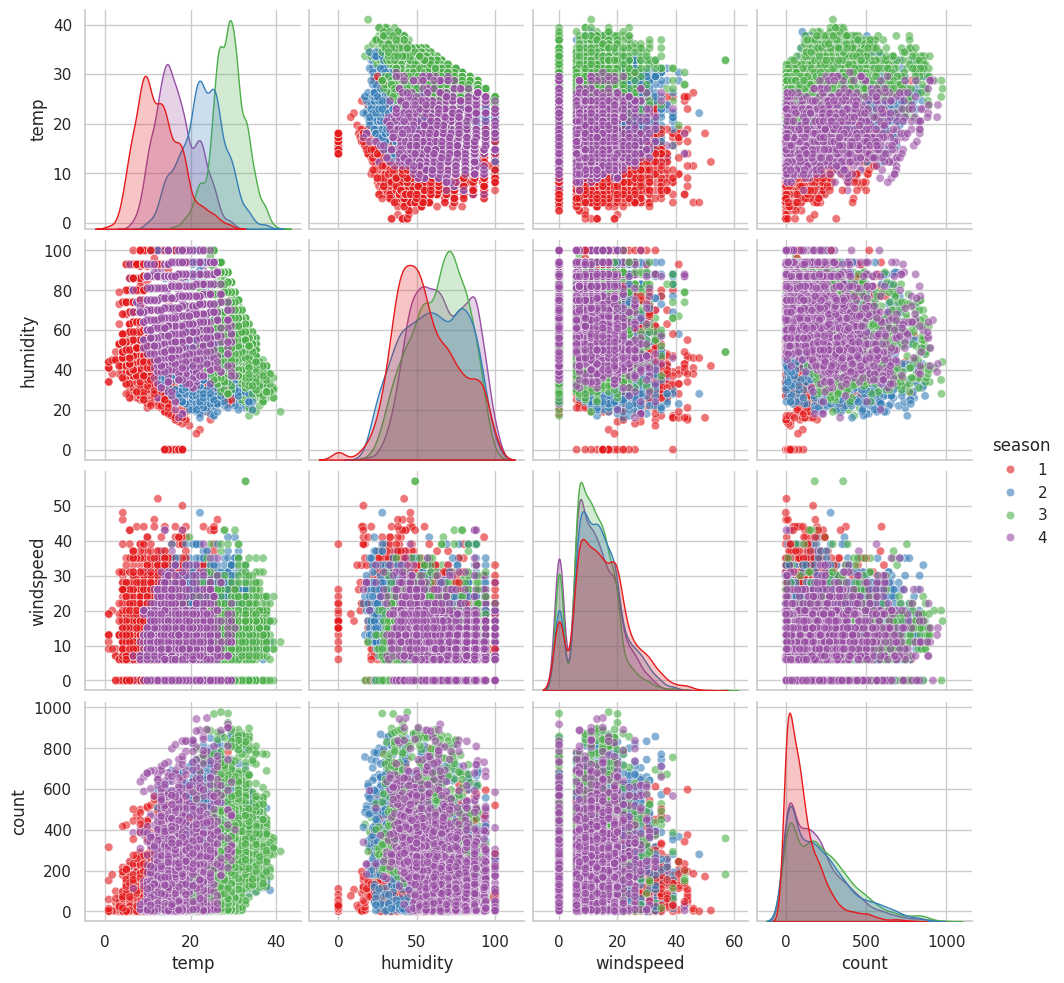

In [12]:
# 1. Списочок необхідних числових змінних разом з категорією для hue
selected_cols = ['temp', 'humidity', 'windspeed', 'count', 'season']

# 2. Побудова Pairplot
sns.pairplot(
    data=df[selected_cols],
    hue='season',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

1. **Між якими змінними спостерігається найсильніший лінійний зв'язок?**

Між temp (температурою) та count (кількістю оренд) - на скатерплоті видно чіткий виражений тренд: зі зростанням температури зростає й кількість оренд (позитивний зв'язок). Змінна humidity також демонструє помірний негативний зв'язок з count.

2. **Яка характеристика найбільше відрізняється між кварталами (сезонами)?**

temp (температура) - на діагональних графіках (KDE розподілу) криві температури для різних сезонів майже повністю розділені: зимовий сезон знаходиться у зоні найнижчих температур, а літній — у зоні найвищих, тоді як humidity та windspeed мають значно більше перекриття між сезонами.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

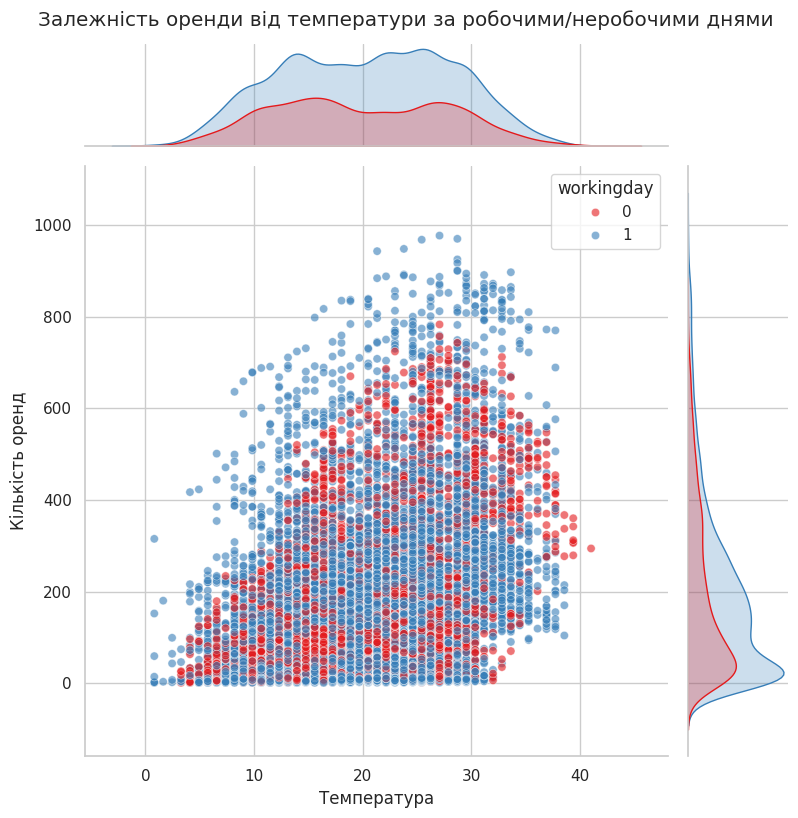

In [13]:
# Побудова Joint Plot
g = sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday',
    palette='Set1',
    alpha=0.6,
    height=8
)

g.fig.suptitle('Залежність оренди від температури за робочими/неробочими днями', y=1.02)
g.set_axis_labels('Температура', 'Кількість оренд')

plt.show()

1. **Що показують графіки по краях?**


Маргінальні графіки (зверху та праворуч) показують одномірні розподіли (KDE або гістограми) кожної окремої змінної:

**Верхній графік:** Розподіл температури (temp) окремо для робочих і неробочих днів.

**Правий графік:** Розподіл кількості оренд (count) для кожної з категорій workingday.


2. **Чи є різниця у поведінці користувачів у робочий і неробочий день?**


**Подібність за температурою:** вплив температури залишається однаковим для обох типів днів — вища температура стимулює зростання кількості оренд.

**Різниця в характері використання:** у робочі дні (workingday = 1) спостерігається вища концентрація оренд у години пік (що формує більш щільний шар середніх і високих значень), оскільки велосипедами користуються як транспортом до роботи/навчання. У неробочі дні (workingday = 0) оренда має більш рівномірний прогулянковий характер протягом дня, але загальні пікові значення при сприятливій температурі залишаються порівнянними.